In [1]:
import pandas as pd
import numpy as np
import zipfile
import os
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
import math

In [2]:
zip_file_path = 'datos_competicion.zip'
extraction_path = 'data'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' unzipped to '{extraction_path}'")

'datos_competicion.zip' unzipped to 'data'


In [3]:
trades = pd.read_csv('data/trades_benchmark.csv')

In [ ]:
# Convert to datetime (keeps timezone correctly)
trades["timestamp_open"] = pd.to_datetime(trades["dateOpen"], format="mixed")
# Remove timezone
trades["timestamp_open"] = trades["timestamp_open"].dt.tz_convert(None)
# Drop seconds and microseconds
trades["timestamp_open"] = trades["timestamp_open"].dt.floor("min")


trades["timestamp_close"] = pd.to_datetime(trades["dateClose"], format="mixed")
# Remove timezone
trades["timestamp_close"] = trades["timestamp_close"].dt.tz_convert(None)
# Drop seconds and microseconds
trades["timestamp_close"] = trades["timestamp_close"].dt.floor("min")


In [7]:
algoritmos_path = r'data/algoritmos'

alg_bench = pd.unique(trades['productname'])
# Get a list of all files in the 'algoritmos' folder
algo_files = [f for f in os.listdir(algoritmos_path) if f.endswith('.csv')]

if algo_files:
    algs_benchmark = [os.path.join(algoritmos_path, name + ".csv") for name in alg_bench]
else:
    print(f"No CSV files found in '{algoritmos_path}'")

In [8]:
horas = set()
fecha_max = datetime(2019,12,31,0,0,0)
fecha_min = datetime(2025,12,31,0,0,0)
for algo in algs_benchmark:

    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'], format = "%Y-%m-%d %H:%M:%S")
    horas.update(pd.unique(df['plot_date']))
    fecha_max_algo = df['plot_date'].max()
    fecha_min_algo = df['plot_date'].min()
    if fecha_max_algo > fecha_max:
        fecha_max = fecha_max_algo
    if fecha_min_algo< fecha_min:
        fecha_min = fecha_min_algo
horas = sorted(list(horas))

In [9]:
df_algoritmos = pd.DataFrame()
df_algoritmos['Date'] = horas

In [10]:
for algo in algs_benchmark:
    name = algo.split('/')[-1].replace('.csv','')
    df = pd.read_csv(algo)
    df['plot_date'] = pd.to_datetime(df['datetime'], format = "%Y-%m-%d %H:%M:%S")
    df_merge = df[['plot_date','open']]
    df_merge.rename(columns = {'open':name}, inplace=True)
    df_algoritmos = df_algoritmos.merge(df_merge[['plot_date',name]], how='left', left_on='Date', right_on='plot_date')
    df_algoritmos.drop(columns = 'plot_date', inplace = True)

#tenemos aquí todos los precios de apertura de todos los algoritmos usados en la cartera a lo largo de sus vidas.
df_algoritmos.fillna(0, inplace=True)

/var/folders/s_/99qyvt911vxdbf2mwngytt8h0000gn/T/ipykernel_82850/2085746507.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge.rename(columns = {'open':name}, inplace=True)
/var/folders/s_/99qyvt911vxdbf2mwngytt8h0000gn/T/ipykernel_82850/2085746507.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge.rename(columns = {'open':name}, inplace=True)
/var/folders/s_/99qyvt911vxdbf2mwngytt8h0000gn/T/ipykernel_82850/2085746507.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

In [13]:
trades['prox_open_hour'] = '-'
trades['prox_close_hour'] = '-'
trades['n_filas'] = 0
trades['precio_open'] = 0
trades['precio_close'] = 0
for index, row in trades.iterrows():
    fecha_open = row['timestamp_open']
    fecha_close = row['timestamp_close']
    try:
        closest_idx_min = (df_algoritmos["Date"] - fecha_open).abs().idxmin()
        closest_idx_max = (df_algoritmos["Date"] - fecha_close).abs().idxmin()
        n_filas = closest_idx_max - closest_idx_min + 1
    except:
        pass
    trades.loc[index, 'prox_open_hour']= df_algoritmos.loc[closest_idx_min,'Date']
    trades.loc[index, 'prox_close_hour']= df_algoritmos.loc[closest_idx_max,'Date']
    trades.loc[index,'n_filas'] = n_filas
    trades.loc[index,'precio_open'] = df_algoritmos.loc[closest_idx_min,row['productname']]
    trades.loc[index,'precio_close'] = df_algoritmos.loc[closest_idx_max,row['productname']]
trades['profit_percentage'] = trades.apply(lambda row:  (row['precio_close'] - row['precio_open'])/row['precio_open']
                                            if (row['precio_open']!=0 and row['precio_close']!=0) else 0, axis = 1)
trades['trade_length'] = (trades['timestamp_close'] - trades['timestamp_open'])/np.timedelta64(1,'D')

/var/folders/s_/99qyvt911vxdbf2mwngytt8h0000gn/T/ipykernel_82850/1056243507.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '90.54' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trades.loc[index,'precio_close'] = df_algoritmos.loc[closest_idx_max,row['productname']]
/var/folders/s_/99qyvt911vxdbf2mwngytt8h0000gn/T/ipykernel_82850/1056243507.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '215.44' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  trades.loc[index,'precio_open'] = df_algoritmos.loc[closest_idx_min,row['productname']]


In [14]:
trades_finalizados = trades.loc[trades['n_filas']!=0]

In [ ]:
#para hacer una evaluación del comportamiento, es importante tener unos cuantos puntos para graficar el comportamiento
#en particular, necesitamos los datos del algoritmo correspondiente para el momento de cierre. 
df_completo = trades_finalizados.loc[(pd.to_datetime(trades_finalizados['prox_close_hour']).dt.day == pd.to_datetime(trades_finalizados['timestamp_close']).dt.day)
    & trades_finalizados['profit_percentage']!=0, ['productname','prox_open_hour','prox_close_hour', 'n_filas','precio_open','precio_close','profit_percentage','trade_length']]
df_completo.reset_index(inplace=True,drop=True)

In [ ]:
#necesitamos una función que normalice funciones con una gaussiana a un dominio común del intervalo [0,1]
def gaussian_kernel_smoother(x, y, x_eval, bandwidth):
    x = np.asarray(x).flatten()
    y = np.asarray(y).flatten()
    x_eval = np.asarray(x_eval).flatten()

    # Compute squared distance matrix
    diff = x_eval[:, None] - x[None, :]

    # Gaussian kernel weights
    weights = np.exp(-0.5 * (diff / bandwidth)**2)

    # Normalize weights
    weights /= np.sum(weights, axis=1, keepdims=True)

    # Smoothed values
    y_smooth = weights @ y
    return y_smooth


In [ ]:
df_completo

,productname,prox_open_hour,prox_close_hour,n_filas,precio_open,precio_close,profit_percentage,trade_length
0,EFKyf,2020-06-03 17:00:00,2020-07-08 09:00:00,149,215.44,222.51,0.032817,34.725694
1,lVhDF,2020-06-03 17:00:00,2020-12-23 06:00:00,868,157.19,144.18,-0.082766,202.574306
2,RsCCj,2020-06-03 17:00:00,2020-07-23 17:00:00,217,207.65,188.86,-0.090489,49.934722
3,yqSyy,2020-06-04 17:00:00,2021-03-05 18:00:00,1165,201.27,210.92,0.047946,274.112500
4,MeTxk,2020-06-11 21:00:00,2020-07-29 13:00:00,203,134.00,136.23,0.016642,47.548611
...,...,...,...,...,...,...,...,...
2540,AmsD8,2024-12-19 14:00:00,2024-12-20 14:00:00,7,148.50,148.61,0.000741,0.999306
2541,UCc87,2024-12-19 14:00:00,2024-12-20 14:00:00,7,86.50,86.35,-0.001734,0.999306
2542,AmsD8,2024-12-24 14:00:00,2024-12-30 14:00:00,19,149.32,149.14,-0.001205,5.999306
2543,2Zc0n,2024-12-24 14:00:00,2024-12-26 14:00:00,7,129.45,129.27,-0.001390,1.999306


In [ ]:
trades_coarse_functions = []
for index, row in df_completo.iterrows():
    precios = [df_algoritmos.loc[(df_algoritmos['Date']>=row['prox_open_hour']) & (df_algoritmos['Date']<=row['prox_close_hour']),row['productname']].values]
    trades_coarse_functions.append([index, np.linspace(0,1,row['n_filas']),np.array(precios)/np.array(precios).mean()])

In [ ]:
x_common = np.linspace(0,1,200)
smooth_functions = []
bandwidth = 0.04
for index_i,x_i,y_i in trades_coarse_functions:
    smooth_functions.append(gaussian_kernel_smoother(x_i,y_i, x_common,bandwidth))


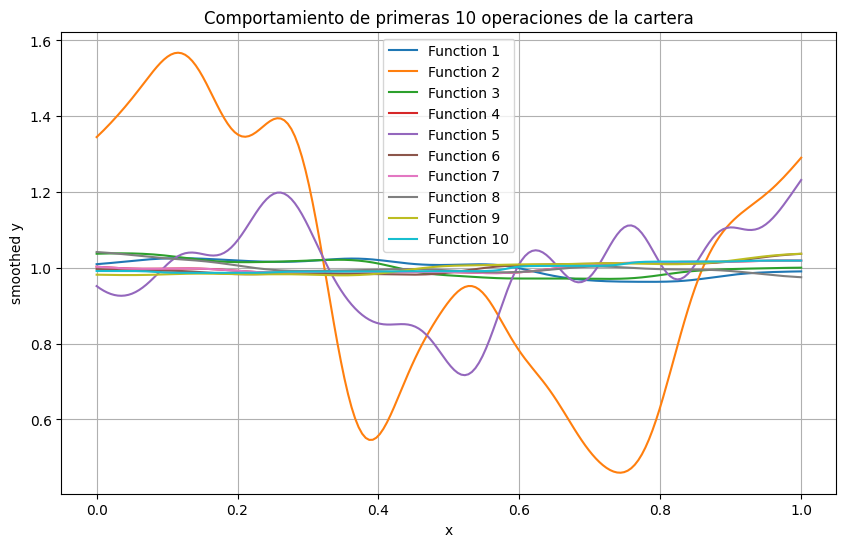

In [ ]:
plt.figure(figsize=(10,6))
for i in range(10):
    plt.plot(x_common, smooth_functions[i], label=f"Function {i+1}")
plt.xlabel("x")
plt.ylabel("smoothed y")
plt.title("Comportamiento de primeras 10 operaciones de la cartera")
plt.legend()
plt.grid(True)
plt.show()

Tenemos que ver si es posible clasificar el comportamiento de los productos antes de que se adquirieran por la cartera (razones para comprar)

In [43]:
trades_history_coarse_functions = []
for index, row in df_completo.iterrows():
    precios_previos = df_algoritmos.loc[(df_algoritmos['Date']<=row['prox_open_hour']) & (df_algoritmos[row['productname']]!=0),row['productname']].values
    trades_history_coarse_functions.append([index, np.linspace(0,1,len(precios_previos[:35])),np.array(precios_previos[:35])/np.array(precios_previos[:35]).mean()])

In [44]:
history_smooth_functions = []
x_common = np.linspace(0,1,200)
andwidth = 0.04
for index_i,x_i,y_i in trades_history_coarse_functions:
    history_smooth_functions.append(gaussian_kernel_smoother(x_i,y_i, x_common,bandwidth))


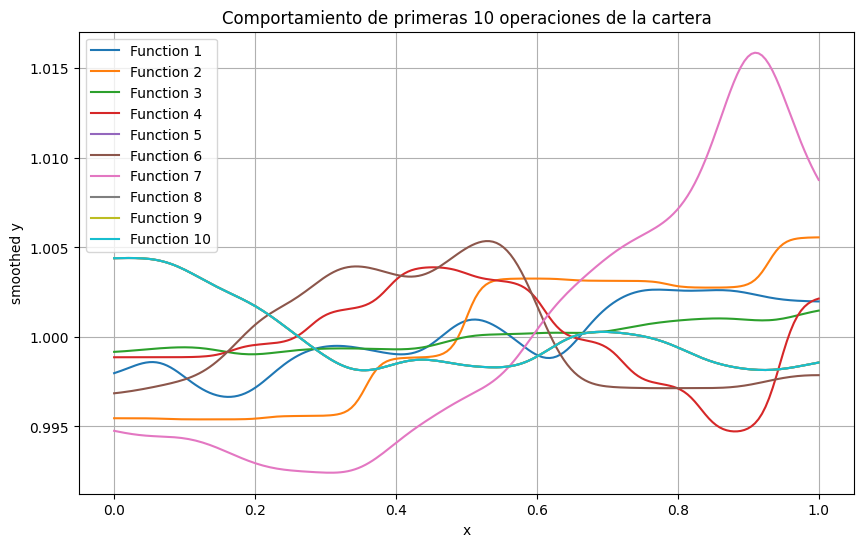

In [45]:
plt.figure(figsize=(10,6))
for i in range(10):
    plt.plot(x_common, history_smooth_functions[i], label=f"Function {i+1}")
plt.xlabel("x")
plt.ylabel("smoothed y")
plt.title("Comportamiento de primeras 10 operaciones de la cartera")
plt.legend()
plt.grid(True)
plt.show()